# Semi-Supervised Learning Pipeline with K-Means & XGBoost

This notebook implements a Semi-Supervised Learning (SSL) workflow designed to maximize the utility of unlabeled data. We combine the speed of K-Means clustering with the high performance of XGBoost to boost classification accuracy in scenarios with limited labeled samples.

1. Workflow Architecture

The pipeline operates through these specific stages:

- Data Split: The training set is split 50/50 into "Labeled" and "Unlabeled" pools.

- XGBoost Baseline: An initial XGBoost model is trained only on the labeled portion to establish a benchmark.

- K-Means Structural Discovery: We cluster the unlabeled data into 10 groups to identify underlying geometric structures in the feature space.

- Pseudo-Labeling: We use the baseline model to predict labels for the unlabeled data, keeping only those where the prediction confidence is >= 95%

- Full Model Training: A final XGBoost model is trained on the combined dataset (Original Labeled + New Pseudo-Labels).

In [27]:
# Imports and environment setup
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from xgboost import XGBClassifier

# Settings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sns.set(style='whitegrid', context='notebook')
print('Environment ready.')

Environment ready.


2. Environment & Configuration

- Model Choice: This version uses XGBClassifier, a gradient boosting framework known for speed and performance.

- K-Means Setup: KMEANS_N_CLUSTERS = 10 is used to partition the unlabeled space.

- Reproducibility: All random seeds are locked to 42 to ensure consistent cluster assignments and model weights across runs.

In [ ]:
# Configuration and utilities
DATASET_CANDIDATES = [
    '../../../dataset/cicids2017_sample_1M_natural_standardized.csv',
]
LABEL_CANDIDATES = ['label', 'Label', 'Attack', 'class', 'Class', 'category', 'target', 'y']

# Semi-supervised settings
TEST_SIZE = 0.2
RECORD_LIMITS = {
    'mode': 'custom',   # 'all' or 'custom'
    'train_n': 100000,
    'test_n': 50000,
}
LABELED_FRAC = 0.5
PSEUDO_THRESHOLD = 0.95
SAMPLE_FRAC = None
RANDOM_STATE = 42

# KMeans settings
KMEANS_N_CLUSTERS = 2

def pick_existing_path(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    return None

def load_any_dataset(candidates):
    path = pick_existing_path(candidates)
    if path is None:
        raise FileNotFoundError('No dataset found: ' + str(candidates))
    df = pd.read_parquet(path) if path.endswith('.parquet') else pd.read_csv(path, low_memory=False)
    print(f'Loaded: {path} | shape={df.shape}')
    return df

def find_label_col(df, candidates=LABEL_CANDIDATES):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError('Label column not found. Checked: ' + str(candidates))

def select_numeric_features(df):
    X_num = df.select_dtypes(include=[np.number])
    if X_num.shape[1] == 0:
        X_num = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all').select_dtypes(include=[np.number])
    return X_num

def stratified_labeled_unlabeled_split(X, y, labeled_frac=0.5, random_state=42):
    sss = StratifiedShuffleSplit(1, test_size=1 - labeled_frac, random_state=random_state)
    labeled_idx, unlabeled_idx = next(sss.split(np.arange(len(y)), y))
    return labeled_idx, unlabeled_idx

def plot_conf_matrix(cm, classes, title='Confusion matrix'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(title)
    plt.tight_layout(); plt.show()

print('Config ready.')


Config ready.


3. Preprocessing & Leakage Protection 

To ensure the scientific validity of the results:

- Binary Mapping: Labels are simplified into Normal (0) and Abnormal (1).

- Feature Scaling: We use a StandardScaler fitted exclusively on the labeled training data. This prevents the model from gaining "future knowledge" about the distribution of the test set.

In [ ]:
# Load, preprocess, and split data
df = load_any_dataset(DATASET_CANDIDATES)
if SAMPLE_FRAC and 0 < SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)

label_col = find_label_col(df)
df = df.dropna(how='any').reset_index(drop=True)

y_raw = df[label_col].astype(str)
X_num = select_numeric_features(df.drop(columns=[label_col]))

# Drop inf rows and extreme-value columns
inf_mask = np.isinf(X_num.values).any(axis=1)
if inf_mask.sum():
    X_num, y_raw = X_num[~inf_mask].reset_index(drop=True), y_raw[~inf_mask].reset_index(drop=True)
extreme_cols = (X_num.abs() > np.finfo(np.float64).max / 2).any()
if extreme_cols.any():
    X_num = X_num.loc[:, ~extreme_cols]

train_features = X_num.columns.tolist()

# Binary encode: Normal=0, Abnormal=1; stratify on original multi-class labels
le_full = LabelEncoder()
y_all = le_full.fit_transform(y_raw)
y_enc = np.where(y_raw.str.lower().isin(['benign', 'normal']), 0, 1).astype(int)
classes = ['Normal', 'Abnormal']
strat_y = y_all if np.bincount(y_all).min() >= 2 else y_enc

if RECORD_LIMITS.get('mode') == 'custom':
    train_n, test_n = RECORD_LIMITS.get('train_n'), RECORD_LIMITS.get('test_n')
    sss = StratifiedShuffleSplit(1, train_size=train_n, test_size=test_n, random_state=RANDOM_STATE)
    train_idx, test_idx = next(sss.split(np.arange(len(y_enc)), strat_y))
    X_train, X_test = X_num.values[train_idx], X_num.values[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_num.values, y_enc, test_size=TEST_SIZE, stratify=strat_y, random_state=RANDOM_STATE)

labeled_idx, unlabeled_idx = stratified_labeled_unlabeled_split(X_train, y_train, LABELED_FRAC, RANDOM_STATE)
X_labeled, y_labeled = X_train[labeled_idx], y_train[labeled_idx]
X_unlabeled = X_train[unlabeled_idx]

scaler = StandardScaler()
X_labeled_s   = scaler.fit_transform(X_labeled)
X_unlabeled_s = scaler.transform(X_unlabeled)
X_test_s      = scaler.transform(X_test)
print(f'Features={len(train_features)} | Train={X_train.shape[0]} (labeled={len(y_labeled)}, unlabeled={len(X_unlabeled)}) | Test={X_test.shape[0]}')


Loaded dataset: ../../../dataset/cicids2017_sample_1M_natural_standardized.csv | shape=(864031, 79)
Detected label column: Label
Dropping 275 rows containing inf/-inf values.
Using numeric features: 78
Binary classes: ['Normal', 'Abnormal']
Stratifying on original multi-class labels to preserve attack-type distribution.
Train: (100000, 78) Test: (50000, 78)
Labeled: (50000, 78) | Unlabeled: (50000, 78)
Scaling complete.


4. Supervised Baseline 

The first XGBoost model is trained. This represents the "status quo"—how well we can do with only the data we have confirmed labels for.

- Key Metric: We focus on the Macro-F1 Score, which balances Precision and Recall for both Normal and Abnormal classes.

Baseline supervised (labeled fraction=0.50) results:
              precision    recall  f1-score   support

      Normal     0.9996    0.9995    0.9996     37091
    Abnormal     0.9986    0.9988    0.9987     12909

    accuracy                         0.9993     50000
   macro avg     0.9991    0.9992    0.9991     50000
weighted avg     0.9993    0.9993    0.9993     50000



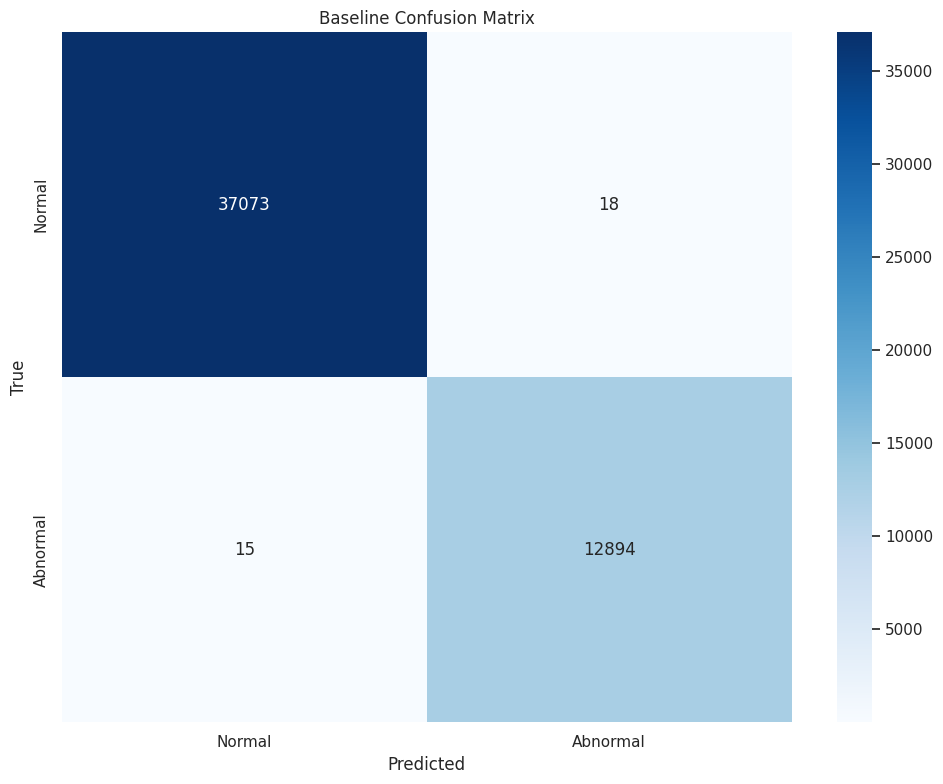

Baseline macro-F1: 0.9991385503236339


In [ ]:
# Baseline (labeled data only)
baseline = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                         use_label_encoder=False, eval_metric='logloss',
                         random_state=RANDOM_STATE, n_jobs=-1)
baseline.fit(X_labeled_s, y_labeled)
y_pred_base = baseline.predict(X_test_s)
print(classification_report(y_test, y_pred_base, labels=[0,1], target_names=classes, digits=4, zero_division=0))
plot_conf_matrix(confusion_matrix(y_test, y_pred_base), classes, 'Baseline Confusion Matrix')
print('Baseline macro-F1:', round(f1_score(y_test, y_pred_base, average='macro'), 4))


5. K-Means & Pseudo-Label Retraining 

This is where the SSL "magic" happens:

- Clustering: K-Means organizes the unlabeled data into K centroids.

- Filtering: We check every unlabeled point. If the baseline XGBoost model is extremely confident (e.g., probability >= 0.95), we "promote" that point into our training set with its predicted label.

- XGBoost SSL: We retrain a fresh XGBoost model on this much larger, augmented dataset.

--- Step 1: KMeans clustering on unlabeled data ---

--- Step 2: Predict pseudo-labels with confidence + cluster-purity filtering ---
Cluster purity report (confidence>=0.95, purity>=80%):
  Cluster  High-conf   Purity   Dominant class  Status
        0      49927     0.74           Normal  rejected
        1          1     1.00           Normal  ACCEPTED

Confident pseudo-labeled samples: 1 / 50000 (0.0%)
  - Threshold >= 0.95 AND cluster purity >= 80%
  Pseudo class Normal: 1

--- Step 3: Retrain model on labeled + pseudo-labeled data ---
Combined training set: 50001 samples (labeled=50000, pseudo=1)

Semi-supervised (KMeans + pseudo-labeling, threshold=0.95) results:
              precision    recall  f1-score   support

      Normal     0.9996    0.9995    0.9996     37091
    Abnormal     0.9986    0.9988    0.9987     12909

    accuracy                         0.9993     50000
   macro avg     0.9991    0.9992    0.9991     50000
weighted avg     0.9993    0.9993    0.9993     5

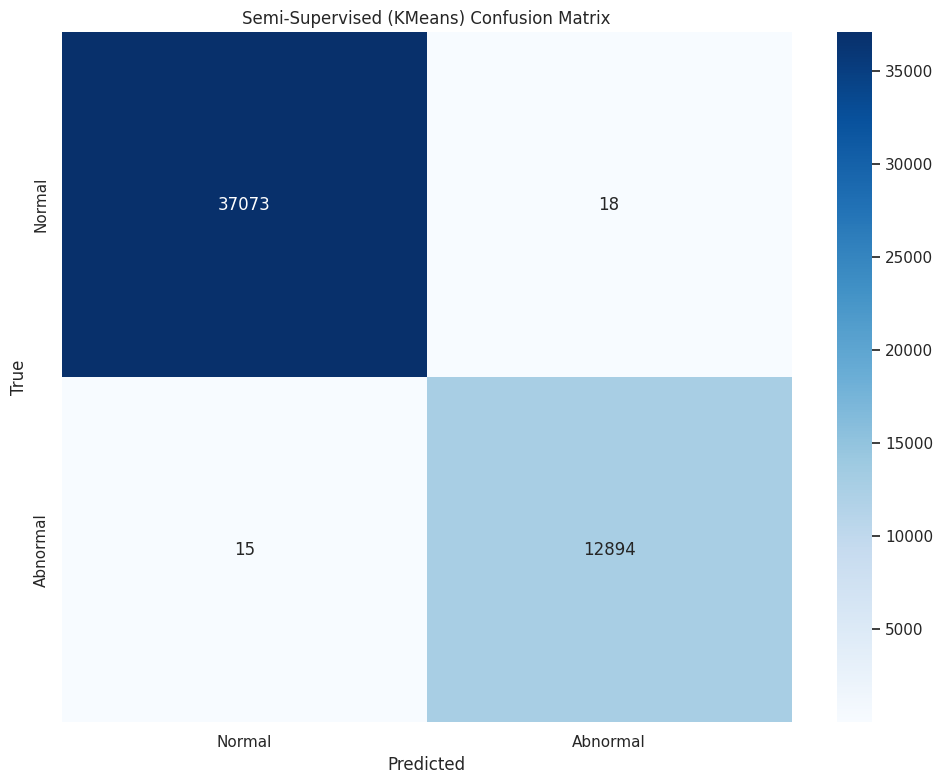

Baseline macro-F1:          0.9991
Semi-supervised macro-F1:   0.9991
Improvement:                +0.0000
Done.


In [ ]:
# Semi-Supervised: KMeans + pseudo-labeling
CLUSTER_PURITY_THRESHOLD = 0.80

clusterer = KMeans(n_clusters=KMEANS_N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
cluster_labels = clusterer.fit_predict(X_unlabeled_s)

proba = baseline.predict_proba(X_unlabeled_s)
max_proba = proba.max(axis=1)
pseudo_preds = baseline.predict(X_unlabeled_s)

# Accept pseudo-labels only from clusters where high-confidence predictions are pure
cluster_pseudo_mask = np.zeros(len(X_unlabeled_s), dtype=bool)
for cid in range(KMEANS_N_CLUSTERS):
    hc = (cluster_labels == cid) & (max_proba >= PSEUDO_THRESHOLD)
    if hc.sum() == 0:
        continue
    preds_hc = pseudo_preds[hc]
    dominant = int(np.bincount(preds_hc).argmax())
    if (preds_hc == dominant).mean() >= CLUSTER_PURITY_THRESHOLD:
        cluster_pseudo_mask |= hc

X_pseudo = X_unlabeled_s[cluster_pseudo_mask]
y_pseudo = pseudo_preds[cluster_pseudo_mask]
print(f'Pseudo-labeled: {cluster_pseudo_mask.sum()}/{len(X_unlabeled_s)} ({cluster_pseudo_mask.mean()*100:.1f}%)')

X_combined = np.vstack([X_labeled_s, X_pseudo])
y_combined = np.concatenate([y_labeled, y_pseudo])

ssl = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                    use_label_encoder=False, eval_metric='logloss',
                    random_state=RANDOM_STATE, n_jobs=-1)
ssl.fit(X_combined, y_combined)

y_pred_ssl = ssl.predict(X_test_s)
print(classification_report(y_test, y_pred_ssl, labels=[0,1], target_names=classes, digits=4, zero_division=0))
plot_conf_matrix(confusion_matrix(y_test, y_pred_ssl), classes, 'SSL (KMeans) Confusion Matrix')
f1_base = f1_score(y_test, y_pred_base, average='macro')
f1_ssl  = f1_score(y_test, y_pred_ssl,  average='macro')
print(f'Macro-F1 — Baseline: {f1_base:.4f}  SSL: {f1_ssl:.4f}  Δ: {f1_ssl - f1_base:+.4f}')


7. Artifact Export 

Saves the results of the experiment into the artifacts/ folder:

- baseline_xgb.joblib: The initial model.

- ssl_xgb.joblib: The enhanced model, including the K-Means clusterer and the scaler used.

In [33]:
# Save trained models and preprocessing artifacts (K-Means + XGBoost version)
import joblib
import os

ART_DIR = 'artifacts'
os.makedirs(ART_DIR, exist_ok=True)
saved = []

if 'baseline' in globals():
    joblib.dump({
        'model': baseline,
        'scaler': scaler,
        'features': train_features,
        'classes': classes,
        'label_encoding': {'normal': 0, 'abnormal': 1}
    }, os.path.join(ART_DIR, 'baseline_xgb.joblib'))
    saved.append('baseline_xgb.joblib')

if 'ssl' in globals():
    joblib.dump({
        'model': ssl,            
        'kmeans_model': clusterer,     
        'scaler': scaler,            
        'features': train_features,
        'classes': classes,
        'label_encoding': {'normal': 0, 'abnormal': 1},
        'kmeans_params': {
            'n_clusters': KMEANS_N_CLUSTERS,
            'init': 'k-means++',
        },
        'xgb_params': ssl.get_params() 
    }, os.path.join(ART_DIR, 'ssl_xgb.joblib'))
    saved.append('ssl_xgb.joblib')

print('---')
print('Artifacts directory:', ART_DIR)
print('Saved files:', saved if saved else 'Nothing saved (Check variable names: baseline_xgb or ssl_xgb).')

---
Artifacts directory: artifacts
Saved files: ['baseline_xgb.joblib', 'ssl_xgb.joblib']
